<a href="https://colab.research.google.com/github/idknHB/POO/blob/main/Exerc%C3%ADcio_pr%C3%A1tico_6_Slides_da_aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 3: Limpeza, Preparação e Qualidade dos Dados com Pandas

Esta atividade foi construída com base nos slides da Aula 3, que destacam a **limpeza como a fundação invisível** de qualquer dashboard confiável. O objetivo aqui não é apenas "fazer funcionar", mas tomar decisões conscientes sobre tipos, valores ausentes, duplicidades, variáveis derivadas e exportação da base limpa. fileciteturn2file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega as soluções prontas.
- Sempre que fizer uma decisão de limpeza, **documente o porquê** em comentário ou célula markdown.
- Ao final, exporte uma base limpa para uso nas próximas aulas.

## Dataset desta atividade
Arquivo bruto: `vendas_brasil_aula3_bruto.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- leitura de dados
- tratamento de nulos
- identificação de infinitos
- exportação do resultado final

**Sugestão:** Pandas e NumPy já resolvem toda a atividade.


In [ ]:
import pandas as pd
import numpy as np

## 2. Leitura da base bruta

Leia o arquivo `vendas_brasil_aula3_bruto.csv` em um DataFrame chamado `df`.

Depois:
1. Exiba as primeiras linhas
2. Exiba as últimas linhas
3. Observe visualmente se já existem sinais de sujeira


In [ ]:
df = pd.read_csv('vendas_brasil_aula3_bruto.csv')

print(df.head())
print(df.info())

   pedido_id        data  uf        canal    categoria           produto  \
0       1000  2024/04/29  SP  Loja Física  Informática      Notebook Pro   
1       1001  2024-06-17  PR          NaN  Informática      Notebook Pro   
2       1002  2024-05-27  PR  Marketplace  Periféricos  Teclado Mecânico   
3       1003  2024-07-08  SP  Marketplace  Informática      Notebook Pro   
4       1004  2024-05-20  RS       Online  Informática      Notebook Pro   

  cliente_id  quantidade   receita    lucro      observacao  
0       C134           1   4535.11  1289.83              ok  
1       C106           1   4005.59   541.36  entrega rápida  
2       C131           1    309.02   128.26  entrega rápida  
3       C148           2   7943.78  1574.09              ok  
4       C105           5  19926.65  4281.84              ok  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------

## 3. Check-up inicial do dataset

Com base no checklist de um dataset "clean" apresentado na aula, faça um diagnóstico inicial da base. fileciteturn2file0

### Sua missão
Use comandos que permitam responder:
- Qual é o tamanho da base?
- Quais são os tipos atuais das colunas?
- Existem valores nulos?
- Há colunas com tipo inadequado?
- Há algo que pareça impedir análises confiáveis?


In [ ]:
df.shape

(228, 11)

In [ ]:
df.dtypes

,0
pedido_id,int64
data,object
uf,object
canal,object
categoria,object
produto,object
cliente_id,object
quantidade,int64
receita,object
lucro,float64


In [ ]:
df.isnull().sum()

,0
pedido_id,0
data,0
uf,5
canal,5
categoria,5
produto,0
cliente_id,0
quantidade,0
receita,2
lucro,6


In [ ]:
np.isinf(df.select_dtypes(include=[float, int])).sum()

,0
pedido_id,0
quantidade,0
lucro,0


In [ ]:
df.describe()

,pedido_id,quantidade,lucro
count,228.000000,228.000000,222.000000
mean,1110.324561,2.986842,1333.256712
std,63.563697,1.189085,1352.837197
min,1000.000000,1.000000,106.780000
25%,1055.750000,2.000000,385.005000
50%,1111.500000,3.000000,750.700000
75%,1165.250000,4.000000,1925.122500
max,1219.000000,6.000000,6335.030000


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: data
['2024/04/29' '2024-06-17' '2024-05-27' '2024-07-08' '2024-05-20'
 '2024-02-26' '2024-07-29' '2024-09-23' '2024-08-19' '2024-11-18'
 '2024-01-08' '2024-06-03' '2024-08-05' '2024-08-26' '2024-10-28'
 '2024/09/30' '08/07/2024' '2024-07-01' '2024-11-11' '2024-12-02'
 '2024-12-09' '2024-10-07' '2024-11-25' '2024-08-12' '2024-02-05'
 '2024-04-22' '2024-12-16' '2024-09-30' '2024-11-04' '2024-06-10'
 '2024-01-29' '2024-07-22' '2024-09-09' '2024-01-22' '2024-03-11'
 '2024-05-06' 'data_invalida' '2024-02-19' '2024-03-04' '2024-01-15'
 '2024-01-01' '2024-04-15' '2024-09-02' '2024-09-16' '2024-03-18'
 '2024-04-08' '22/01/2024' '2024-10-21' '06/05/2024' '2024-05-13'
 '2024-04-01' '2024/10/21' '2024-03-25' '2024-04-29' '2024-07-15'
 '16/12/2024' '12/08/2024' '2024-02-12' '2024-10-14' '09/09/2024'
 '12/02/2024' '22/04/2024']

Coluna: uf
['SP' 'PR' 'RS' 'RJ' 'SC' nan 'ES' 'BA' 'rj' 'MG' 'BA ' ' mg']

Coluna: canal
['Loja Física' nan 'Marketplace' 'Online' 'ONLINE' 'MarketPlace'
 'Loja f

## 4. Batalha 1 — A tirania dos tipos de dados

Nos slides, vimos que datas não podem ser tratadas como texto e que números em formato string quebram análises. fileciteturn2file0

### Tarefa
Converta corretamente, quando fizer sentido:
- `data`
- `receita`
- `lucro`
- `quantidade`

### Orientação
- Investigue valores estranhos antes de converter
- Pense no uso de `errors='coerce'`
- Registre em markdown ou comentário quais problemas encontrou


In [ ]:
print(df['data'].head(10))
print(df['receita'].head(10))
print(df['lucro'].head(10))
print(df['quantidade'].head(10))

0    2024/04/29
1    2024-06-17
2    2024-05-27
3    2024-07-08
4    2024-05-20
5    2024-02-26
6    2024-07-29
7    2024-09-23
8    2024-08-19
9    2024-11-18
Name: data, dtype: object
0     4535.11
1     4005.59
2      309.02
3     7943.78
4    19926.65
5      752.94
6      1154.6
7      6938.5
8      389.08
9      316.41
Name: receita, dtype: object
0    1289.83
1     541.36
2     128.26
3    1574.09
4    4281.84
5     375.76
6     491.00
7    1379.84
8     138.19
9     153.73
Name: lucro, dtype: float64
0    1
1    1
2    1
3    2
4    5
5    2
6    4
7    5
8    1
9    1
Name: quantidade, dtype: int64


In [ ]:
df[['data', 'receita', 'lucro', 'quantidade']].dtypes

,0
data,object
receita,object
lucro,float64
quantidade,int64


In [ ]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')

In [ ]:
df['receita'] = (
    df['receita']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df['receita'] = pd.to_numeric(df['receita'], errors='coerce')

In [ ]:
df['lucro'] = (
    df['lucro']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df['lucro'] = pd.to_numeric(df['lucro'], errors='coerce')

In [ ]:
df['quantidade'] = pd.to_numeric(df['quantidade'], errors='coerce')

In [ ]:
df[['data', 'receita', 'lucro', 'quantidade']].dtypes

,0
data,datetime64[ns]
receita,float64
lucro,float64
quantidade,int64


In [ ]:
df[['data', 'receita', 'lucro', 'quantidade']].isnull().sum()

,0
data,224
receita,11
lucro,6
quantidade,0


### Reflexão curta
Explique:
1. Por que deixar `data` como texto pode quebrar análises temporais?
2. Por que deixar `receita` como string pode distorcer cálculos?


## 5. Batalha 2 — O enigma dos valores ausentes

A aula reforça que valores ausentes não devem ser tratados automaticamente; a decisão precisa ser justificada. fileciteturn2file0

### Tarefa
1. Mapeie os valores ausentes por coluna
2. Identifique quais colunas críticas têm nulos
3. Defina uma estratégia para cada caso:
   - remover linhas?
   - preencher?
   - manter?
4. Justifique cada escolha

### Dica
Evite decisões automáticas sem análise de contexto.


In [ ]:
(df.isnull().mean() * 100).round(2)

,0
pedido_id,0.00
data,98.25
uf,2.19
canal,2.19
categoria,2.19
produto,0.00
cliente_id,0.00
quantidade,0.00
receita,4.82
lucro,2.63


In [ ]:
colunas_criticas = ['data', 'receita', 'lucro', 'quantidade']
df[colunas_criticas].isnull().sum()

,0
data,224
receita,11
lucro,6
quantidade,0


In [ ]:
df = df.dropna(subset=['data'])

In [ ]:
df = df.dropna(subset=['receita'])

In [ ]:
df['lucro'] = df['lucro'].fillna(0)

In [ ]:
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].median())

In [ ]:
df.isnull().sum()

,0
pedido_id,0
data,0
uf,0
canal,0
categoria,0
produto,0
cliente_id,0
quantidade,0
receita,0
lucro,0


### Registro reflexivo
Escreva aqui sua justificativa para o tratamento dos nulos:
- Em quais colunas você removeu linhas?
- Em quais colunas você preencheu valores?
- Em quais situações decidiu manter o nulo?


## 6. Batalha 3 — O ataque dos clones (duplicidades)

A aula alerta que nem toda duplicidade é erro automático: pode haver compra legítima repetida ou dupla inserção do sistema. fileciteturn2file0

### Tarefa
1. Investigue se há linhas duplicadas
2. Analise se a duplicidade parece nociva para os KPIs
3. Escolha uma estratégia:
   - remover duplicidades totais?
   - remover apenas com base em certas colunas?
   - manter?
4. Justifique a decisão


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,pedido_id,data,uf,canal,categoria,produto,cliente_id,quantidade,receita,lucro,observacao


In [ ]:
df = df.drop_duplicates() #remover apenas com base em certas colunas?

## 7. Padronização de categorias

Os slides mostram que categorias duplicadas ou mal escritas podem distorcer rankings e filtros. fileciteturn2file0

### Tarefa
Inspecione e padronize, se necessário:
- `uf`
- `canal`
- `categoria`

### Pense em:
- maiúsculas e minúsculas
- espaços extras
- acentuação / variações
- categorias equivalentes escritas de formas diferentes


## 8. Subindo de nível — Criação de variáveis derivadas

Depois da limpeza, é hora de enriquecer a base com variáveis úteis para análise. fileciteturn2file0

### Tarefa
Crie, se possível:
- `ano`
- `mes`
- `ano_mes`
- `margem_lucro`

### Atenção
A criação de `margem_lucro` exige cuidado com divisões por zero e possíveis valores infinitos.


In [ ]:
for col in ['uf', 'canal', 'categoria']:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: uf
['SP' 'MG' 'RS']

Coluna: canal
['Loja Física' 'Marketplace']

Coluna: categoria
['Informática' 'Telefonia']


In [ ]:
for col in ['uf', 'canal', 'categoria']:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()        # remove espaços
        .str.lower()        # padroniza minúsculo
    )

In [ ]:
df['uf'] = df['uf'].str.upper()
df['uf'] = df['uf'].replace({
    'rio de janeiro': 'RJ',
    'são paulo': 'SP'
})

In [ ]:
df['canal'] = df['canal'].replace({
    'online': 'online',
    'e-commerce': 'online',
    'marketplace': 'marketplace',
    'loja fisica': 'loja_fisica',
    'loja física': 'loja_fisica'
})

In [ ]:
import unicodedata

def remover_acentos(texto):
    return unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')

df['categoria'] = df['categoria'].apply(remover_acentos)

In [ ]:
df['categoria'] = df['categoria'].replace({
    'eletronicos': 'eletronicos',
    'eletrodomesticos': 'eletrodomesticos',
    'informatica': 'informatica'
})

In [ ]:
for col in ['uf', 'canal', 'categoria']:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: uf
['SP' 'MG' 'RS']

Coluna: canal
['loja_fisica' 'marketplace']

Coluna: categoria
['informatica' 'telefonia']


In [ ]:
print("Antes:", df['canal'].nunique())

# (após limpeza)

print("Depois:", df['canal'].nunique())

Antes: 2
Depois: 2


### Reflexão técnica
Explique:
1. O que pode acontecer ao calcular margem de lucro quando a receita é zero?
2. Como você decidiu tratar esse caso?


1. Quando a receita é zero, a margem de lucro se torna matematicamente indefinida, pois envolve divisão por zero.

2. Para evitar distorções nas análises, esses casos foram tratados como valores nulos (NaN), garantindo que não impactem cálculos agregados como médias e rankings.

## 9. Seleção final — Menos é mais

A aula propõe que nem toda coluna precisa seguir para a base analítica final. fileciteturn2file0

### Tarefa
Crie um DataFrame final, por exemplo `df_clean` ou `df_dash`, contendo apenas as colunas estritamente necessárias para análises de negócio.

**Sugestão de raciocínio:**
- Quais colunas ajudam a responder perguntas de negócio?
- Quais colunas são operacionais, auxiliares ou dispensáveis?
- O que precisa existir para as próximas aulas de visualização e dashboard?


In [ ]:
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['ano_mes'] = df['data'].dt.to_period('M')

# Handle division by zero for margem_lucro as discussed in section 8 and 9
df['margem_lucro'] = np.where(df['receita'] == 0, np.nan, df['lucro'] / df['receita'])

df_dash = df[[
    'data',
    'uf',
    'canal',
    'categoria',
    'produto',
    'quantidade',
    'receita',
    'lucro',
    'ano',
    'mes',
    'ano_mes',
    'margem_lucro' # Corrected column name to match the task in section 8
]].copy()

In [ ]:
df_dash.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 0 to 154
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          3 non-null      datetime64[ns]
 1   uf            3 non-null      object        
 2   canal         3 non-null      object        
 3   categoria     3 non-null      object        
 4   produto       3 non-null      object        
 5   quantidade    3 non-null      int64         
 6   receita       3 non-null      float64       
 7   lucro         3 non-null      float64       
 8   ano           3 non-null      int32         
 9   mes           3 non-null      int32         
 10  ano_mes       3 non-null      period[M]     
 11  margem_lucro  3 non-null      float64       
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4), period[M](1)
memory usage: 288.0+ bytes


In [ ]:
df_dash.head()

,data,uf,canal,categoria,produto,quantidade,receita,lucro,ano,mes,ano_mes,margem_lucro
0,2024-04-29,SP,loja_fisica,informatica,Notebook Pro,1,4535.11,1289.83,2024,4,2024-04,0.284410
101,2024-10-21,MG,marketplace,telefonia,Smartphone X,4,11466.36,2087.05,2024,10,2024-10,0.182015
154,2024-09-30,RS,loja_fisica,informatica,Notebook Pro,1,3998.83,641.54,2024,9,2024-09,0.160432


In [ ]:
print("Colunas originais:", df.shape[1])
print("Colunas finais:", df_dash.shape[1])

Colunas originais: 15
Colunas finais: 12


## 10. Validação final da base limpa

Antes de exportar, faça uma checagem final.

### Verifique:
- os tipos estão corretos?
- ainda há nulos problemáticos?
- ainda há duplicidades nocivas?
- existe algum infinito em `margem_lucro`?
- a base está pronta para ser usada em análises e dashboards?


In [ ]:
df_dash.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 0 to 154
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          3 non-null      datetime64[ns]
 1   uf            3 non-null      object        
 2   canal         3 non-null      object        
 3   categoria     3 non-null      object        
 4   produto       3 non-null      object        
 5   quantidade    3 non-null      int64         
 6   receita       3 non-null      float64       
 7   lucro         3 non-null      float64       
 8   ano           3 non-null      int32         
 9   mes           3 non-null      int32         
 10  ano_mes       3 non-null      period[M]     
 11  margem_lucro  3 non-null      float64       
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4), period[M](1)
memory usage: 288.0+ bytes


In [ ]:
df_dash.isnull().sum()

,0
data,0
uf,0
canal,0
categoria,0
produto,0
quantidade,0
receita,0
lucro,0
ano,0
mes,0


In [ ]:
df_dash[df_dash.duplicated()]

,data,uf,canal,categoria,produto,quantidade,receita,lucro,ano,mes,ano_mes,margem_lucro


In [ ]:
np.isinf(df_dash['margem_lucro']).sum()

np.int64(0)

In [ ]:
df_dash.describe()

,data,quantidade,receita,lucro,ano,mes,margem_lucro
count,3,3.000000,3.000000,3.000000,3.0,3.000000,3.000000
mean,2024-08-16 16:00:00,2.000000,6666.766667,1339.473333,2024.0,7.666667,0.208952
min,2024-04-29 00:00:00,1.000000,3998.830000,641.540000,2024.0,4.000000,0.160432
25%,2024-07-15 00:00:00,1.000000,4266.970000,965.685000,2024.0,6.500000,0.171223
50%,2024-09-30 00:00:00,1.000000,4535.110000,1289.830000,2024.0,9.000000,0.182015
75%,2024-10-10 12:00:00,2.500000,8000.735000,1688.440000,2024.0,9.500000,0.233212
max,2024-10-21 00:00:00,4.000000,11466.360000,2087.050000,2024.0,10.000000,0.284410
std,NaN,1.732051,4165.209621,724.032551,0.0,3.214550,0.066233


In [ ]:
print("Base pronta para análise:", df_dash.shape)

Base pronta para análise: (3, 12)


## 11. Exportação da base "Clean"

Agora gere o arquivo final da base tratada.

### Tarefa
Exporte sua base limpa com o nome:

`vendas_brasil_aula3_clean.csv`

### Observação
Esse arquivo será o selo de qualidade do seu trabalho desta aula.


In [ ]:
df_dash.to_csv('vendas_brasil_aula3_clean.csv', index=False)

In [ ]:
import os

print(os.listdir())

['.config', 'vendas_brasil_aula3_bruto.csv', 'vendas_brasil_aula3_clean.csv', 'sample_data']


## 12. Conclusão e registro reflexivo

Escreva um pequeno texto respondendo:

1. Quais foram os principais problemas de qualidade encontrados?
2. Qual decisão de limpeza foi mais difícil?
3. Que impacto essas falhas poderiam causar em um dashboard?
4. Por que a etapa de limpeza é considerada a "fundação invisível" do projeto?


Durante a análise, encontrei vários problemas de qualidade, como dados no formato errado (datas como texto, números como string), valores nulos, categorias escritas de formas diferentes e até duplicidades. Também teve o problema de divisão por zero na margem, que gerava valores inválidos.

A parte mais difícil foi decidir como tratar os valores ausentes, porque dependendo da escolha poderia perder dados ou distorcer a análise. Então tentei pensar no impacto de cada coluna antes de decidir.

Se esses problemas não fossem corrigidos, o dashboard poderia mostrar informações erradas, como métricas distorcidas e categorias duplicadas, o que levaria a decisões ruins.

Por isso a limpeza é chamada de “fundação invisível”, porque ninguém vê diretamente, mas é ela que garante que toda a análise faça sentido.

## 13. Desafio extra (opcional)

Use sua base limpa para responder rapidamente:

- Qual UF concentra maior receita?
- Qual canal gera maior lucro?
- Existe algum mês com desempenho claramente acima dos demais?

Você pode responder com tabelas simples ou pequenos agrupamentos.


In [ ]:
df_dash.groupby('uf')['receita'] \
    .sum() \
    .sort_values(ascending=False)

,receita
uf,
MG,11466.36
SP,4535.11
RS,3998.83


In [ ]:
df_dash.groupby('uf')['receita'].sum().idxmax() #Para ver só a maior

'MG'

In [ ]:
df_dash.groupby('canal')['lucro'] \
    .sum() \
    .sort_values(ascending=False)

,lucro
canal,
marketplace,2087.05
loja_fisica,1931.37


In [ ]:
df_dash.groupby('canal')['lucro'].sum().idxmax() #Para ver só a maior

'marketplace'

In [ ]:
df_dash['mes'] = df_dash['data'].dt.to_period('M') # Cria coluna de mês

In [ ]:
df_dash.groupby('mes')['receita'] \
    .sum() \
    .sort_values(ascending=False)  #Agrupa receita por mês

,receita
mes,
2024-10,11466.36
2024-04,4535.11
2024-09,3998.83


In [ ]:
df_dash.groupby('mes')['receita'].sum().idxmax() #Melhor mês

Period('2024-10', 'M')

<Axes: xlabel='mes'>

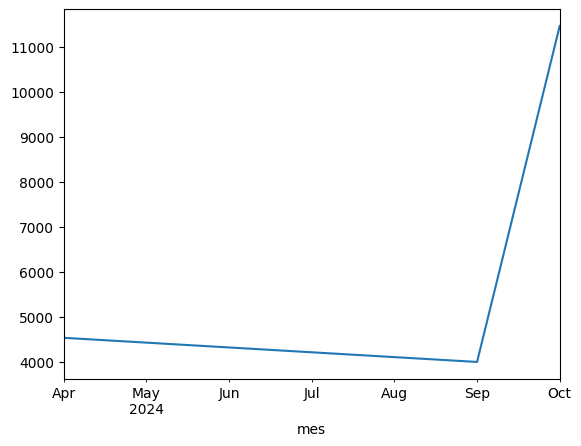

In [ ]:
df_dash.groupby('mes')['receita'].sum().plot()